In [ ]:
#Pandas
import pandas as pd

#graficas
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))
#vectorizacicón de texto
from sklearn.feature_extraction.text import TfidfVectorizer
#División de texto
from sklearn.model_selection import train_test_split

#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC



url="https://docs.google.com/spreadsheets/d/1QnduVFuFBuuzbTDigcy7RVGuy4FF2d-l8gKWOhrLbyg/export?format=csv&gid=0"
#url="https://objectstorage.mx-queretaro-1.oraclecloud.com/p/t19Yz5Ndw4o2nggEJbtJCh24dcNksWToFzAr8v3j_Q5mRnFRCFUD37ZiyK4AZdgf/n/axsuszsnqvkf/b/bucket-hackathon/o/base_de_datosBase%20-%20Hoja%201.csv"

df = pd.read_csv(url)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df.head()

,titulo,texto,categoria
0,Fundamentos de Node.js en el Servidor,Node.js permite crear servidores backend usand...,Backend
1,El Protocolo HTTP en la Web,HTTP es el protocolo que usan los clientes y s...,Backend
2,Principios y Verbos de una API REST,"Una API REST usa verbos como GET, POST, PUT y ...",Backend
3,Ventajas y Configuración de Spring Boot,Spring Boot facilita crear aplicaciones Java a...,Backend
4,Rol del Servidor Backend,Un servidor backend recibe solicitudes y devue...,Backend


#1.Exploración y limpieza de datos (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   titulo     320 non-null    object
 1   texto      320 non-null    object
 2   categoria  320 non-null    object
dtypes: object(3)
memory usage: 7.6+ KB


In [ ]:
df.columns

Index(['titulo', 'texto', 'categoria'], dtype='object')

##Verificando Datos Nulos O Vacios


In [ ]:
df.isnull().sum()

,0
titulo,0
texto,0
categoria,0


In [ ]:

# 1. Verificación
nulos_iniciales = df.isnull().sum().sum()
print(f"Cantidad total de nulos detectados: {nulos_iniciales}")

# 2. Aplicar limpieza si existen nulos en columnas críticas
if nulos_iniciales > 0:
    # Elimina filas donde falte el texto o la categoría
    df = df.dropna(subset=['titulo','texto', 'categoria']).reset_index(drop=True)
    print(f"✅ Nulos eliminados. Tamaño actual del dataset: {df.shape}")
else:
    print("✅ No se encontraron nulos.")

Cantidad total de nulos detectados: 0
✅ No se encontraron nulos.


##Verificando Duplicados


In [ ]:
# Verificar registros duplicados
duplicados = df.duplicated().sum()

print(f"Cantidad total de registros duplicados: {duplicados}")

Cantidad total de registros duplicados: 0


##Verificando Formatos


In [ ]:
print(df.dtypes)

titulo       object
texto        object
categoria    object
dtype: object


In [ ]:
# Eliminar espacios al inicio y al final
df["titulo"] = df["titulo"].str.strip()
df["texto"] = df["texto"].str.strip()
df["categoria"] = df["categoria"].str.strip()

print(" Espacios eliminados.")

 Espacios eliminados.


In [ ]:
#Verificando texto (palabras iguales)
print(df["categoria"].unique())


['Backend' 'Frontend' 'BasesDeDatos' 'IA' 'Cloud' 'Fronted'
 'Bases de datos']


In [ ]:
df["categoria"] = df["categoria"].replace({
    "Fronted":"Frontend",
    "Bases de datos":"BasesDeDatos"
})

In [ ]:
print(df["categoria"].unique())

['Backend' 'Frontend' 'BasesDeDatos' 'IA' 'Cloud']


##Analizando Volumen Del Dataset

In [ ]:
print("Dimensiones del dataset:")
print(df.shape)

print(f"\nNúmero de registros: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del dataset:
(320, 3)

Número de registros: 320
Número de columnas: 3


In [ ]:
#Buscando el balance de categorias
conteo = df["categoria"].value_counts()

print(conteo)

categoria
Cloud           69
BasesDeDatos    66
Backend         63
Frontend        62
IA              60
Name: count, dtype: int64


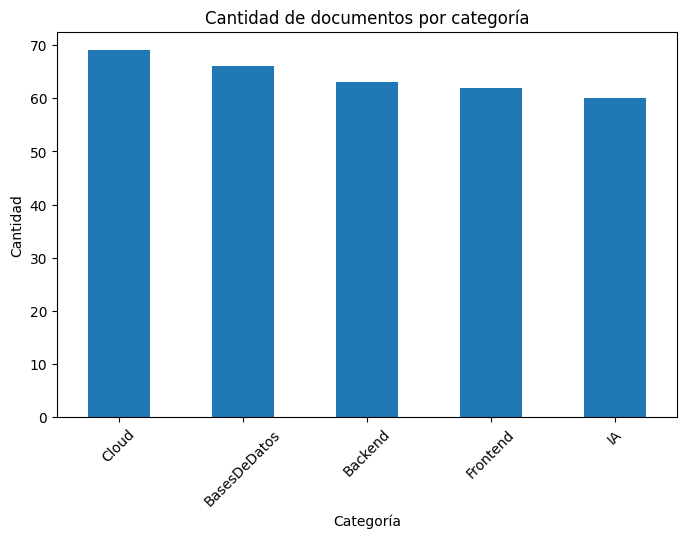

In [ ]:


plt.figure(figsize=(8,5))

df["categoria"].value_counts().plot(kind="bar")

plt.title("Cantidad de documentos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

plt.show()

#2.Tratamientos de textos


##Convertir Minusculas


In [ ]:
df['texto'] = df['texto'].str.lower()
df['titulo'] = df['titulo'].str.lower()
df['categoria'] = df['categoria'].str.lower()

df.head()

,titulo,texto,categoria
0,fundamentos de node.js en el servidor,node.js permite crear servidores backend usand...,backend
1,el protocolo http en la web,http es el protocolo que usan los clientes y s...,backend
2,principios y verbos de una api rest,"una api rest usa verbos como get, post, put y ...",backend
3,ventajas y configuración de spring boot,spring boot facilita crear aplicaciones java a...,backend
4,rol del servidor backend,un servidor backend recibe solicitudes y devue...,backend


##Eliminacion De Signos De Puntuacion


In [ ]:
#Eliminación de signos en textos

df['texto'] = df['texto'].str.replace(r'[^\w\s]|_', '', regex=True)


##Eliminar Stopwords

In [ ]:
def eliminar_stopwords(texto):
  if isinstance(texto,str): #asegura que sea texto
    palabras=texto.split() #transformación en lista
    palabras_filtradas=[p for p in palabras if p not in stop_words]
    return ' '.join(palabras_filtradas)
    return texto

In [ ]:
df['texto']=df['texto'].apply(eliminar_stopwords)

df.head()

,titulo,texto,categoria
0,fundamentos de node.js en el servidor,nodejs permite crear servidores backend usando...,backend
1,el protocolo http en la web,http protocolo usan clientes servidores comuni...,backend
2,principios y verbos de una api rest,api rest usa verbos get post put delete maneja...,backend
3,ventajas y configuración de spring boot,spring boot facilita crear aplicaciones java p...,backend
4,rol del servidor backend,servidor backend recibe solicitudes devuelve r...,backend


#3.Transformación de datos al formato adecuado para modelado

##Definición de variables


In [ ]:
# Variables independientes (Texto)
X = df['titulo'] + " " + df['texto']
#x = df['texto']
# Variable objetivo (Categoría)
y = df['categoria']


print("Variable x:")
print(x.head())

print("\nVariable y:")
print(y.head())

Variable x:
0    nodejs permite crear servidores backend usando...
1    http protocolo usan clientes servidores comuni...
2    api rest usa verbos get post put delete maneja...
3    spring boot facilita crear aplicaciones java p...
4    servidor backend recibe solicitudes devuelve r...
Name: texto, dtype: object

Variable y:
0    backend
1    backend
2    backend
3    backend
4    backend
Name: categoria, dtype: object


##Vectorización del Texto (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
x_vectorizado = vectorizer.fit_transform(x)

In [ ]:
print(x_vectorizado.shape)

(320, 1425)


320 documentos.
1425 palabras únicas

"Utilizamos TF-IDF para transformar cada documento de texto en un vector numérico. El vectorizador construye un vocabulario con todas las palabras únicas del conjunto de entrenamiento y calcula un peso para cada palabra según su importancia en cada documento. El modelo de clasificación no trabaja con texto directamente, sino con esos vectores numéricos, lo que le permite aprender patrones y predecir la categoría de nuevos contenidos."

##División del Dataset


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(

  x,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

##Verificación de dimensiones

In [ ]:
print("Entrenamiento:", x_train.shape)
print("Prueba:", x_test.shape)

print("Etiquetas entrenamiento:", y_train.shape)
print("Etiquetas prueba:", y_test.shape)


Entrenamiento: (256,)
Prueba: (64,)
Etiquetas entrenamiento: (256,)
Etiquetas prueba: (64,)


#4.Entrenamiento y evaluación de modelos

Usaremos los modelos:

-Logistic Regression

-Multinomial Naive Bayes

-Linear SVC

##Importación de modelos


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer


##Creación de Pipeline

In [ ]:
#Pipeline Logistic Regression
pipeline_LR = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", LogisticRegression(random_state=42))
    ])

In [ ]:
#Pipeline Multinomial Naive Bayes
pipeline_NB = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", MultinomialNB())
])

In [ ]:
#Pipeline Linear SVC
pipeline_SVC = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", LinearSVC(random_state=42))
])

##Validación cruzada

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
#Scores de Logistic Regression
scores_LR = cross_val_score(
    pipeline_LR,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
    )
print(scores_LR)
print("Accuracy promedio:", scores_LR.mean())

[0.90384615 0.84313725 0.84313725 0.84313725 0.78431373]
Accuracy promedio: 0.8435143288084465


In [ ]:
#Scores de Multinomial Naive Bayes
scores_NB = cross_val_score(
    pipeline_NB,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
    )
print(scores_NB)
print("Accuracy promedio:", scores_NB.mean())

[0.86538462 0.78431373 0.8627451  0.78431373 0.76470588]
Accuracy promedio: 0.8122926093514329


In [ ]:
#Scores de Linear SVC
scores_SVC = cross_val_score(
    pipeline_SVC,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
    )
print(scores_SVC)
print("Accuracy promedio:", scores_SVC.mean())

[0.86538462 0.82352941 0.8627451  0.8627451  0.84313725]
Accuracy promedio: 0.8515082956259427


In [ ]:
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVC"
    ],
    "Accuracy Promedio": [
        scores_LR.mean(),
        scores_NB.mean(),
        scores_SVC.mean()
    ]
})

comparacion = comparacion.sort_values(
    by="Accuracy Promedio",
    ascending=False
).reset_index(drop=True)

comparacion

,Modelo,Accuracy Promedio
0,Linear SVC,0.851508
1,Logistic Regression,0.843514
2,Naive Bayes,0.812293


##Entrenamiento

In [ ]:
#Entrenamiento
pipeline_SVC.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('modelo', LinearSVC(random_state=42))])

In [ ]:
#Predicción
pred_SVC = pipeline_SVC.predict(x_test)

##Evaluación de métricas

###Accuracy: ¿Cuántas predicciones acertó de todas las realizadas?

In [ ]:
from sklearn.metrics import accuracy_score
accuracy =  accuracy_score(y_test, pred_SVC)
print(f"El modelo acerto el {accuracy:.4f} de las prediccones del conjunto de prueba")

El modelo acerto el 0.8750 de las prediccones del conjunto de prueba


###Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_SVC))

              precision    recall  f1-score   support

     backend       0.92      0.85      0.88        13
basesdedatos       0.91      0.77      0.83        13
       cloud       0.87      0.93      0.90        14
    frontend       0.91      0.83      0.87        12
          ia       0.80      1.00      0.89        12

    accuracy                           0.88        64
   macro avg       0.88      0.88      0.87        64
weighted avg       0.88      0.88      0.87        64



###Matriz de Confusión

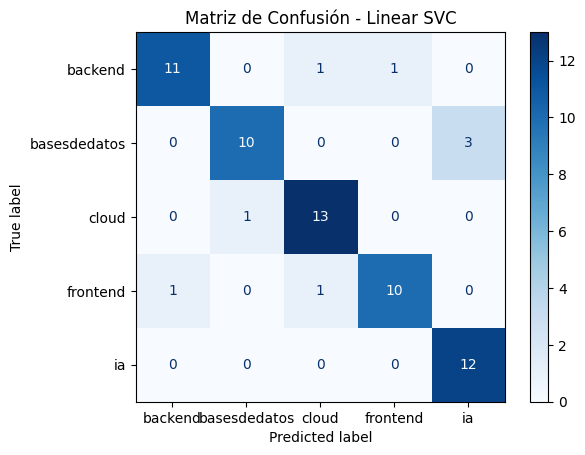

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_SVC,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Linear SVC")

plt.show()

##Guardar

In [ ]:
#Guardamos pipeline que usara la API
import joblib

In [ ]:
joblib.dump(pipeline_SVC, "pipeline_clasificador.joblib")

['pipeline_clasificador.joblib']

##Probando el modelo

cargamos


In [ ]:
modelo = joblib.load("pipeline_clasificador.joblib")

Pruebas

In [ ]:
texto = [
    "Curso de Java y Spring Boot para crear APIs REST"
]

In [ ]:
modelo.predict(texto)

array(['backend'], dtype=object)

In [ ]:
texto = [
    "Fundamentos de Machine Learning utilizando Python y Scikit-Learn"
]

modelo.predict(texto)

array(['ia'], dtype=object)

In [ ]:
from google.colab import files

files.download("pipeline_clasificador.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>